<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1200px-Pandas_logo.svg.png" width="25%" height="25%" />

# Pandas - Topic 08 - Data Manipulation Part 1

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> 

## Topic Objectives

* **Rename** DataFrame columns
* **Select** columns based on their data type
* **Convert** Pandas DataFrames to NumPy arrays

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Package for Learning

In [1]:
import numpy as np
import pandas as pd

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

# Pandas - Topic 08 - Data Manipulation Part 1

In this notebook, we will cover

* how to rename your DataFrame columns with `.columns` and `.rename()`
* how to select data based on their type with `.select_dtypes()`
* how to convert Pandas DataFrames to NumPy array with `.values`

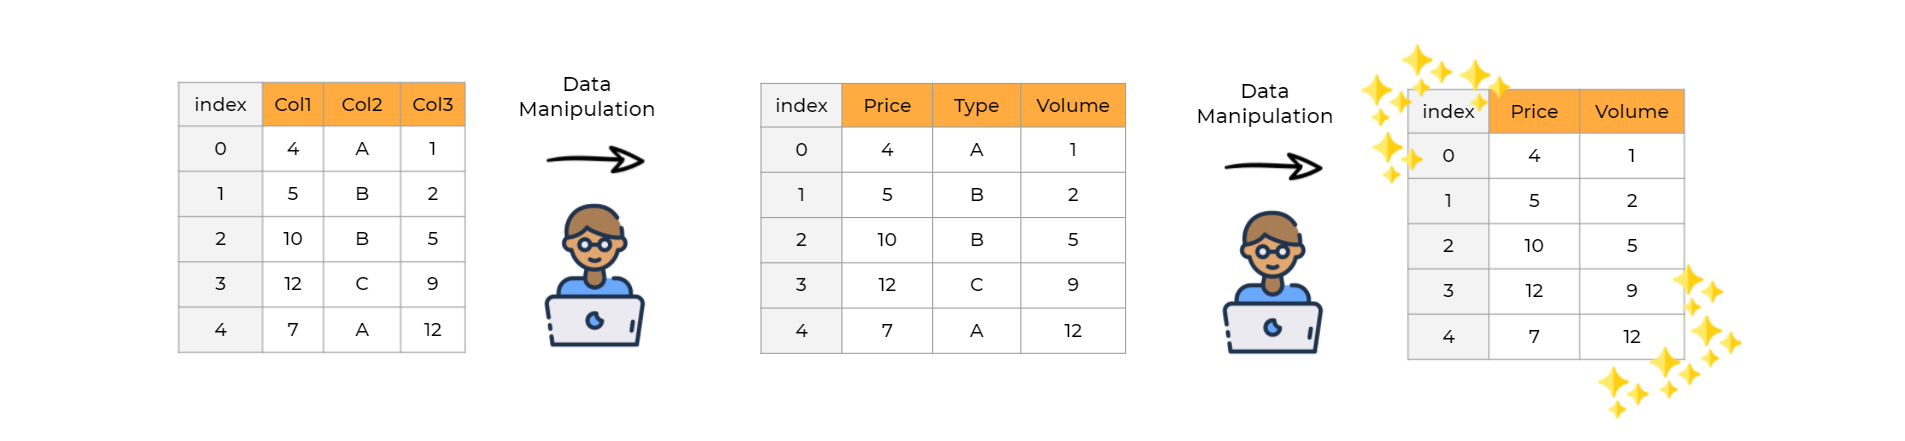

---

Consider the dataset from the previous unit

In [2]:
df = pd.DataFrame(data={'Col1':np.random.randint(low=0,high=50,size=10),
                        'Col2':np.random.randn(10),
                        'Col3':['A','B','C','A','A','C','D','B','A','A'],
                        'Col4':np.random.choice([True, False],size=10),
                        'Col5':np.random.randint(low=1,high=4,size=10)},
                  index=pd.date_range(start='01/01/2021', periods=10, freq='M'))
df

/tmp/ipykernel_24594/2898990506.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.date_range(start='01/01/2021', periods=10, freq='M'))


,Col1,Col2,Col3,Col4,Col5
2021-01-31,41,2.447272,A,False,3
2021-02-28,18,-0.169409,B,False,2
2021-03-31,48,-0.492075,C,False,1
2021-04-30,4,-0.372616,A,False,1
2021-05-31,31,-0.058565,A,False,1
2021-06-30,33,1.218837,C,False,2
2021-07-31,30,0.415349,D,False,2
2021-08-31,0,-0.294388,B,True,2
2021-09-30,32,-0.069007,A,False,3
2021-10-31,27,-0.638037,A,False,2


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Rename Columns

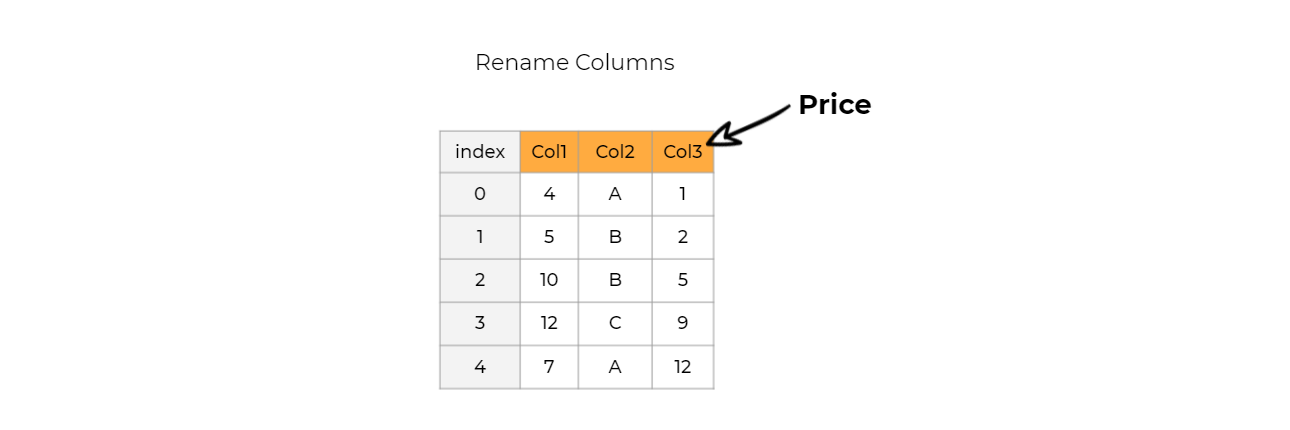

In [3]:
df_example = df.copy()
df_example.head()

,Col1,Col2,Col3,Col4,Col5
2021-01-31,41,2.447272,A,False,3
2021-02-28,18,-0.169409,B,False,2
2021-03-31,48,-0.492075,C,False,1
2021-04-30,4,-0.372616,A,False,1
2021-05-31,31,-0.058565,A,False,1


Then we assign to `df.columns` a list with the column names we want

In [4]:
df_example.columns = ['Revenue', 'Rate', 'ProfileCategory', 'Flag', 'ClassCategory']
df_example.head()

,Revenue,Rate,ProfileCategory,Flag,ClassCategory
2021-01-31,41,2.447272,A,False,3
2021-02-28,18,-0.169409,B,False,2
2021-03-31,48,-0.492075,C,False,1
2021-04-30,4,-0.372616,A,False,1
2021-05-31,31,-0.058565,A,False,1


Alternatively you can use `.rename()`. The documentation is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rename.html). You should parse a list mapping the old column names and new column names using the 'columns' argument. Note we set `inplace=True`, to overwrite the DataFrame



  * This is **useful and can save time** when you have a long list of columns and don't want to list all the column names. You just map to rename the columns in which you are interested in changing. In this example, we just mapped three columns. The others remain the same.

In [5]:
df_example = df.copy()
df_example = df_example.rename(columns={"Col1":"Revenue",
                                        "Col2":"Rate",
                                        'Col4':'Flag'})
df_example.head()

,Revenue,Rate,Col3,Flag,Col5
2021-01-31,41,2.447272,A,False,3
2021-02-28,18,-0.169409,B,False,2
2021-03-31,48,-0.492075,C,False,1
2021-04-30,4,-0.372616,A,False,1
2021-05-31,31,-0.058565,A,False,1


We can use the argument `inplace=True` as an alternative. This creates a new DataFrame. The difference is that you don't have to reassign the variable.

In [6]:
df_example = df.copy()
df_example.rename(columns={"Col1":"Revenue",
                           "Col2":"Rate",
                           'Col4':'Flag'},inplace=True)
df_example.head()

,Revenue,Rate,Col3,Flag,Col5
2021-01-31,41,2.447272,A,False,3
2021-02-28,18,-0.169409,B,False,2
2021-03-31,48,-0.492075,C,False,1
2021-04-30,4,-0.372616,A,False,1
2021-05-31,31,-0.058565,A,False,1


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: Consider the dataset which consists of 10,000 customers mentioning their age, salary, marital_status, credit card limit, credit card category, etc. Such datasets are used to predict how many clients stop using a product (churned) so management can proactively go to the customer to provide them better services and reverse customers' decisions.

In [7]:
df_practice = pd.read_csv("data/BankChurners.csv")
df_practice.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


Rename `CLIENTNUM` for ClientID, `Attrition_Flag` for TargetValue and `Dependent_count` for Children
* You don't have to overwrite the DataFrame

Your output should look like

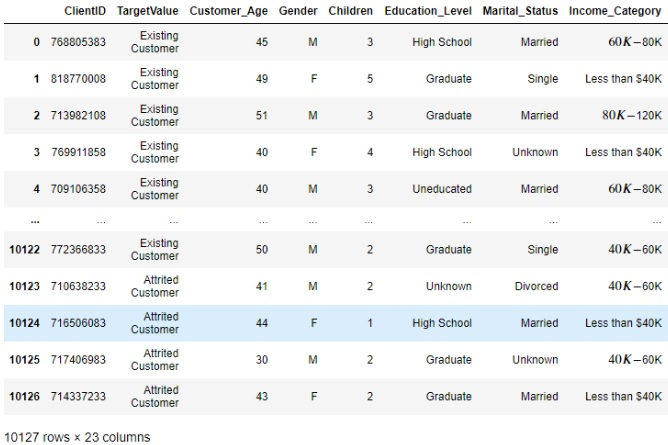

In [8]:
# write your code here
df_practice.rename(columns={
    'CLIENTNUM':'ClientID',
    'Attrition_Flag':'TargetValue',
    'Dependent_count':'Children',
})

,ClientID,TargetValue,Customer_Age,Gender,Children,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Selecting data based on data types

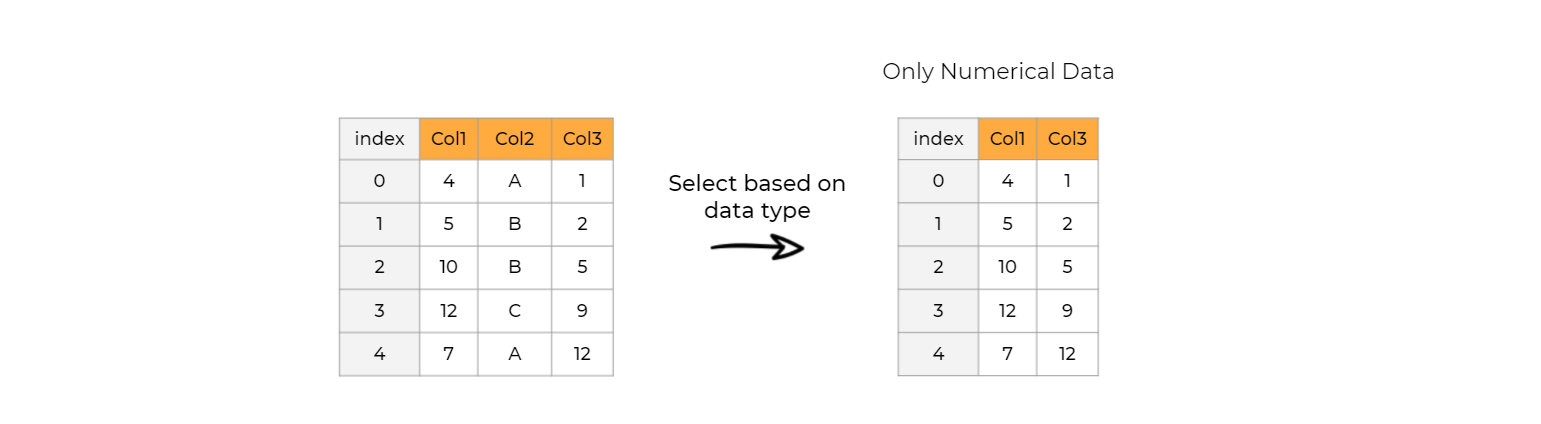

Let's recap `df` first

In [9]:
df

,Col1,Col2,Col3,Col4,Col5
2021-01-31,41,2.447272,A,False,3
2021-02-28,18,-0.169409,B,False,2
2021-03-31,48,-0.492075,C,False,1
2021-04-30,4,-0.372616,A,False,1
2021-05-31,31,-0.058565,A,False,1
2021-06-30,33,1.218837,C,False,2
2021-07-31,30,0.415349,D,False,2
2021-08-31,0,-0.294388,B,True,2
2021-09-30,32,-0.069007,A,False,3
2021-10-31,27,-0.638037,A,False,2


You can select data based on data type with `.select_dtypes()`. This function documentation is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html)
* Say you are interested to subset only numerical data, you should set the "`include`" argument as '`number`'
* You might do this if you want to create a scatterplot 

In [10]:
df.select_dtypes(include='number')

,Col1,Col2,Col5
2021-01-31,41,2.447272,3
2021-02-28,18,-0.169409,2
2021-03-31,48,-0.492075,1
2021-04-30,4,-0.372616,1
2021-05-31,31,-0.058565,1
2021-06-30,33,1.218837,2
2021-07-31,30,0.415349,2
2021-08-31,0,-0.294388,2
2021-09-30,32,-0.069007,3
2021-10-31,27,-0.638037,2


Now you are interested to subset only categorical data; you should set the "`include`" argument as '`object`'

In [11]:
df.select_dtypes(include='object')

,Col3
2021-01-31,A
2021-02-28,B
2021-03-31,C
2021-04-30,A
2021-05-31,A
2021-06-30,C
2021-07-31,D
2021-08-31,B
2021-09-30,A
2021-10-31,A


If you want boolean data, set the '`include`' argument as '`boolean`'

In [12]:
df.select_dtypes(include='boolean')

,Col4
2021-01-31,False
2021-02-28,False
2021-03-31,False
2021-04-30,False
2021-05-31,False
2021-06-30,False
2021-07-31,False
2021-08-31,True
2021-09-30,False
2021-10-31,False


If you want a combination of multiple data types, parse them in a list.
  * The example below considers boolean and number types

In [13]:
df.select_dtypes(include=['boolean','number'])

,Col1,Col2,Col4,Col5
2021-01-31,41,2.447272,False,3
2021-02-28,18,-0.169409,False,2
2021-03-31,48,-0.492075,False,1
2021-04-30,4,-0.372616,False,1
2021-05-31,31,-0.058565,False,1
2021-06-30,33,1.218837,False,2
2021-07-31,30,0.415349,False,2
2021-08-31,0,-0.294388,True,2
2021-09-30,32,-0.069007,False,3
2021-10-31,27,-0.638037,False,2


For the next example, we create a separate DataFrame df1, and reset the index of df.
  * The previous index became a column called '`index`'

In [14]:
df1 = df.reset_index()
df1

,index,Col1,Col2,Col3,Col4,Col5
0,2021-01-31,41,2.447272,A,False,3
1,2021-02-28,18,-0.169409,B,False,2
2,2021-03-31,48,-0.492075,C,False,1
3,2021-04-30,4,-0.372616,A,False,1
4,2021-05-31,31,-0.058565,A,False,1
5,2021-06-30,33,1.218837,C,False,2
6,2021-07-31,30,0.415349,D,False,2
7,2021-08-31,0,-0.294388,B,True,2
8,2021-09-30,32,-0.069007,A,False,3
9,2021-10-31,27,-0.638037,A,False,2


We now want to select from df1, the columns where the datatype is equal to '`datetime`'

In [15]:
df1.select_dtypes(include='datetime')

,index
0,2021-01-31
1,2021-02-28
2,2021-03-31
3,2021-04-30
4,2021-05-31
5,2021-06-30
6,2021-07-31
7,2021-08-31
8,2021-09-30
9,2021-10-31


You can also reverse logic, and use the `exclude` parameter when you don't want a specific data type in your DataFrame.
* Naturally, you can use it for all the data types we showed earlier
* We will showcase using 'number' only

In [16]:
df.select_dtypes(exclude='number')

,Col3,Col4
2021-01-31,A,False
2021-02-28,B,False
2021-03-31,C,False
2021-04-30,A,False
2021-05-31,A,False
2021-06-30,C,False
2021-07-31,D,False
2021-08-31,B,True
2021-09-30,A,False
2021-10-31,A,False


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

 **PRACTICE**: Consider `df_practice`. Select only categorical variables

Your output should look like

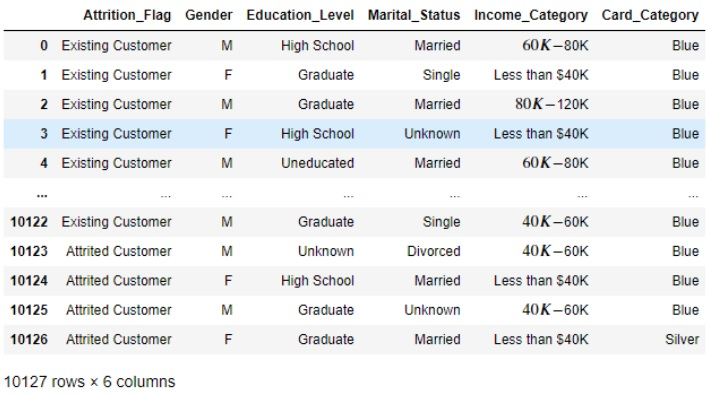

In [17]:
# write your code here
df_practice.select_dtypes(include='object')

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
0,Existing Customer,M,High School,Married,$60K - $80K,Blue
1,Existing Customer,F,Graduate,Single,Less than $40K,Blue
2,Existing Customer,M,Graduate,Married,$80K - $120K,Blue
3,Existing Customer,F,High School,Unknown,Less than $40K,Blue
4,Existing Customer,M,Uneducated,Married,$60K - $80K,Blue
...,...,...,...,...,...,...
10122,Existing Customer,M,Graduate,Single,$40K - $60K,Blue
10123,Attrited Customer,M,Unknown,Divorced,$40K - $60K,Blue
10124,Attrited Customer,F,High School,Married,Less than $40K,Blue
10125,Attrited Customer,M,Graduate,Unknown,$40K - $60K,Blue


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

###  Convert a Pandas DataFrame to a NumPy array

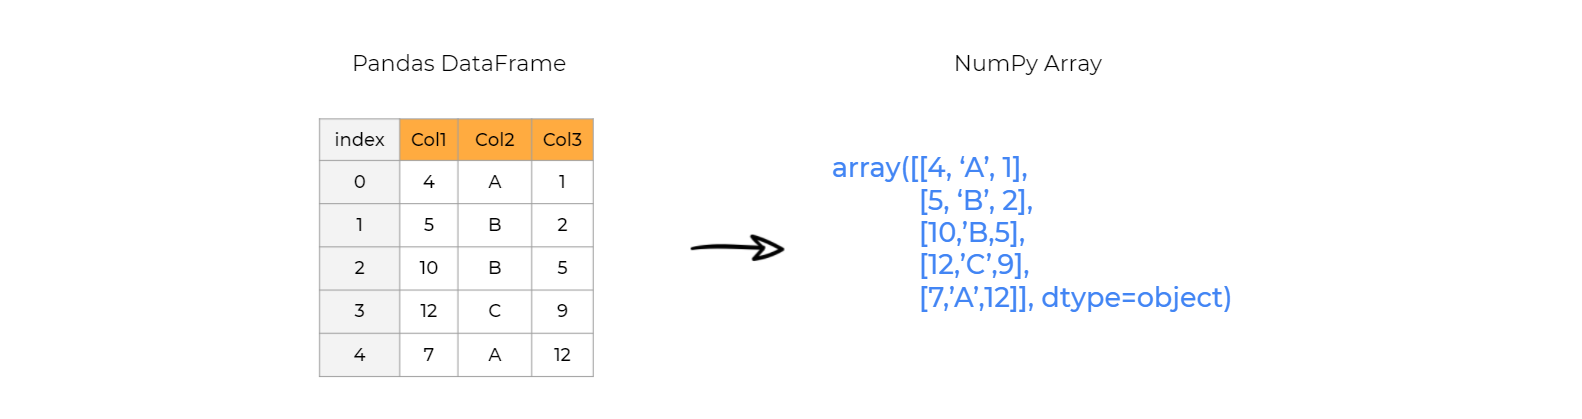

You can convert a Pandas DataFrame to a NumPy Array with `.to_numpy()`
  * This operation is needed for future lessons when training machine learning models since some of them need the data as an array
  * Just a quick recap on df

In [18]:
df

,Col1,Col2,Col3,Col4,Col5
2021-01-31,41,2.447272,A,False,3
2021-02-28,18,-0.169409,B,False,2
2021-03-31,48,-0.492075,C,False,1
2021-04-30,4,-0.372616,A,False,1
2021-05-31,31,-0.058565,A,False,1
2021-06-30,33,1.218837,C,False,2
2021-07-31,30,0.415349,D,False,2
2021-08-31,0,-0.294388,B,True,2
2021-09-30,32,-0.069007,A,False,3
2021-10-31,27,-0.638037,A,False,2


Now converting to an array. Note the index is not included

In [19]:
df.to_numpy()

array([[41, 2.4472717266520387, 'A', False, 3],
       [18, -0.16940946002033522, 'B', False, 2],
       [48, -0.4920754550047768, 'C', False, 1],
       [4, -0.3726160035072242, 'A', False, 1],
       [31, -0.058565234502822305, 'A', False, 1],
       [33, 1.2188366794383725, 'C', False, 2],
       [30, 0.41534944803624013, 'D', False, 2],
       [0, -0.29438836815001823, 'B', True, 2],
       [32, -0.06900658901774291, 'A', False, 3],
       [27, -0.6380373286103135, 'A', False, 2]], dtype=object)

Alternatively, you can convert it to a NumPy array using the attribute `.values`

In [20]:
df.values

array([[41, 2.4472717266520387, 'A', False, 3],
       [18, -0.16940946002033522, 'B', False, 2],
       [48, -0.4920754550047768, 'C', False, 1],
       [4, -0.3726160035072242, 'A', False, 1],
       [31, -0.058565234502822305, 'A', False, 1],
       [33, 1.2188366794383725, 'C', False, 2],
       [30, 0.41534944803624013, 'D', False, 2],
       [0, -0.29438836815001823, 'B', True, 2],
       [32, -0.06900658901774291, 'A', False, 3],
       [27, -0.6380373286103135, 'A', False, 2]], dtype=object)